# Notebook 08: Data Sufficiency


In [8]:
import json
import time
from pathlib import Path

import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import RidgeCV
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

try:
    from lightgbm import LGBMRegressor
except ImportError:
    LGBMRegressor = None


## 1. Load Data & Setup

This notebook uses the same feature setup as the modeling notebooks. It is artifact-driven: if teammates save metadata in the same pattern under `artifacts/<model_name>/`, this notebook will discover and run the supported models automatically.


In [9]:
train = pd.read_csv('clean_data/train.csv', parse_dates=['week_start'])
test = pd.read_csv('clean_data/test.csv', parse_dates=['week_start'])

cat_cols = [c for c in train.columns if c.startswith('cat_id_')]
store_cols = [c for c in train.columns if c.startswith('store_id_')]

for df in [train, test]:
    df['cat_id'] = df[cat_cols].idxmax(axis=1).str.replace('cat_id_', '')
    df['store_id'] = df[store_cols].idxmax(axis=1).str.replace('store_id_', '')

target = 'weekly_units'
drop_cols = (['wm_yr_wk', 'week_start', 'n_days', 'month', 'week_of_year', 
              'cat_id', 'store_id', target]
             + cat_cols + store_cols 
             + [c for c in train.columns if c.startswith('state_id_')])
feature_cols = [c for c in train.columns if c not in drop_cols]

combos = sorted(train.groupby(['store_id', 'cat_id']).groups.keys())

train_full = train.copy()
sorted_train_weeks = sorted(train_full['wm_yr_wk'].unique())
val_weeks = sorted_train_weeks[-8:]
train_weeks = sorted_train_weeks[:-8]

train_tune = train_full[train_full['wm_yr_wk'].isin(train_weeks)].copy()
val = train_full[train_full['wm_yr_wk'].isin(val_weeks)].copy()

print('Train tuning shape:', train_tune.shape)
print('Validation shape:', val.shape)
print('Test shape:', test.shape)
print('Feature count:', len(feature_cols))
print('Combos:', len(combos))


Train tuning shape: (6270, 47)
Validation shape: (240, 47)
Test shape: (240, 47)
Feature count: 23
Combos: 30


## 2. Load Saved Artifacts


In [10]:
def load_metadata(path):
    path = Path(path)
    if not path.exists():
        return None
    with open(path, "r") as f:
        return json.load(f)

def load_artifact_bundle(path, metadata_path=None):
    if not path:
        return None
    candidates = [Path(path)]
    if metadata_path is not None:
        candidates.append(Path(metadata_path).parent / Path(path).name)
    for bundle_path in candidates:
        if bundle_path.exists():
            return joblib.load(bundle_path)
    return None

artifact_roots = [Path("artifacts"), Path("../artifacts")]
artifact_paths = []
seen = set()
for root in artifact_roots:
    if not root.exists():
        continue
    for meta_path in sorted(root.glob("*/*_metadata.json")):
        key = meta_path.resolve()
        if key not in seen:
            artifact_paths.append(meta_path)
            seen.add(key)

artifact_registry = {}
registry_rows = []

for metadata_path in artifact_paths:
    meta = load_metadata(metadata_path)
    if meta is None:
        continue
    artifact_key = metadata_path.parent.name
    model_type = meta.get("model_type", artifact_key)
    artifact_file = meta.get("artifact_file")
    bundle = load_artifact_bundle(artifact_file, metadata_path=metadata_path)
    artifact_registry[artifact_key] = {
        "metadata": meta,
        "bundle": bundle,
        "metadata_file": str(metadata_path),
        "artifact_file": artifact_file,
        "model_type": model_type
    }
    registry_rows.append({
        "artifact_key": artifact_key,
        "model_name": meta.get("model_name", artifact_key),
        "model_type": model_type,
        "metadata_file": str(metadata_path),
        "artifact_file": artifact_file,
        "bundle_loaded": bundle is not None
    })

if not artifact_registry:
    raise FileNotFoundError(
        "No saved model artifacts were found under artifacts/*/ or ../artifacts/*/. Run the model notebooks first so notebook_08 can load their configs automatically."
    )

artifact_summary = pd.DataFrame(registry_rows).sort_values(["artifact_key", "metadata_file"]).reset_index(drop=True)
print("Loaded artifact entries:", list(artifact_registry.keys()))
artifact_summary


Loaded artifact entries: ['lightgbm', 'mlp', 'random_forest', 'ridge']


,artifact_key,model_name,model_type,metadata_file,artifact_file,bundle_loaded
0,lightgbm,LightGBM (Pooled),lightgbm,../artifacts/lightgbm/lightgbm_metadata.json,artifacts/lightgbm/lightgbm_pooled_model.joblib,True
1,lightgbm,LightGBM (Pooled),lightgbm,artifacts/lightgbm/lightgbm_metadata.json,artifacts/lightgbm/lightgbm_pooled_model.joblib,True
2,mlp,MLP Final,mlp,artifacts/mlp/mlp_metadata.json,artifacts/mlp/mlp_models.joblib,True
3,random_forest,RandomForest (Pooled),random_forest,../artifacts/random_forest/random_forest_metad...,/Users/aeshagandhi/Downloads/MIDS-Sp26/IDS-705...,True
4,random_forest,RandomForest (Pooled),random_forest,artifacts/random_forest/random_forest_metadata...,artifacts/random_forest/random_forest_pooled_m...,False
5,ridge,Ridge (CV alpha),ridge_cv,artifacts/ridge/ridge_metadata.json,artifacts/ridge/ridge_models.joblib,True


## 3. Experiment Questions

This notebook is answering three questions for each supported model artifact it finds:

1. Can the saved fitted artifacts still be loaded and used directly for prediction?
2. How much historical training data is needed before performance becomes reasonably stable?
3. Does concentrating on the highest-volume store-category combinations preserve enough signal relative to the full training set?

Subsetting design:
- We do not randomly sample rows, because that would break the forecasting structure.
- For size experiments, we use repeated contiguous week windows shared across all series.
- For concentration experiments, we use a deterministic Pareto subset based on combo volume.
- The saved fitted bundles are used for a direct sanity check, but the sufficiency experiments intentionally retrain from each model's saved best configuration.


## 4. Metrics and Generic Runners


In [11]:
def calc_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    safe_y_true = np.where(np.asarray(y_true) == 0, np.nan, np.asarray(y_true))
    mape = np.nanmean(np.abs((np.asarray(y_true) - np.asarray(y_pred)) / safe_y_true)) * 100
    r2 = r2_score(y_true, y_pred)
    return {"MAE": mae, "RMSE": rmse, "MAPE": mape, "R2": r2}

def summarize_runtime(seconds, n_models):
    return {
        "fit_time_total_sec": seconds,
        "fit_time_avg_sec": seconds / n_models if n_models else np.nan
    }

def mlp_param_count(input_dim, hidden_layer_sizes):
    dims = [input_dim] + list(hidden_layer_sizes) + [1]
    total = 0
    for in_dim, out_dim in zip(dims[:-1], dims[1:]):
        total += in_dim * out_dim + out_dim
    return total

def make_contiguous_week_subsets(df, fraction, n_repeats=5):
    weeks = sorted(df["wm_yr_wk"].unique())
    keep_n = max(1, int(np.floor(len(weeks) * fraction)))

    if keep_n >= len(weeks):
        return [(0, df.copy())]

    max_start = len(weeks) - keep_n
    starts = np.linspace(0, max_start, num=min(n_repeats, max_start + 1), dtype=int)
    starts = sorted(set(starts.tolist()))

    subsets = []
    for repeat_id, start in enumerate(starts):
        keep_weeks = weeks[start:start + keep_n]
        subset = df[df["wm_yr_wk"].isin(keep_weeks)].copy()
        subsets.append((repeat_id, subset))
    return subsets

def pareto_subset_by_combo_volume(df, top_share=0.8):
    volume = (
        df.groupby(["store_id", "cat_id"])[target]
        .sum()
        .sort_values(ascending=False)
        .reset_index(name="volume")
    )
    volume["cum_share"] = volume["volume"].cumsum() / volume["volume"].sum()
    keep = volume[volume["cum_share"] <= top_share].copy()
    if keep.empty:
        keep = volume.head(1).copy()
    return df.merge(keep[["store_id", "cat_id"]], on=["store_id", "cat_id"], how="inner")

def get_model_spec(metadata, artifact_key):
    model_type = metadata.get("model_type", artifact_key)
    model_scope = metadata.get("model_scope", "per_combo")
    model_target = metadata.get("target", target)
    model_feature_cols = metadata.get("feature_cols", feature_cols)
    best_config = metadata.get("best_config", {})
    return model_type, model_scope, model_target, model_feature_cols, best_config

def build_model(model_type, best_config, random_state=42):
    if model_type == "mlp":
        return MLPRegressor(
            hidden_layer_sizes=tuple(best_config["hidden_layer_sizes"]),
            activation="relu",
            alpha=best_config["alpha"],
            learning_rate_init=0.001,
            max_iter=1000,
            early_stopping=True,
            validation_fraction=0.15,
            random_state=random_state
        )
    if model_type == "ridge_cv":
        return RidgeCV(alphas=np.array(best_config["alphas"]), cv=best_config["cv"])
    if model_type == "random_forest":
        return RandomForestRegressor(**best_config, n_jobs=-1, random_state=random_state)
    if model_type == "lightgbm":
        if LGBMRegressor is None:
            raise ImportError("lightgbm is not installed in this environment.")
        return LGBMRegressor(**best_config, random_state=random_state, verbose=-1)
    raise ValueError(f"Unsupported model_type: {model_type}")

def run_supported_model(train_df, eval_df, metadata, model_key, random_state=42):
    model_type, model_scope, model_target, model_feature_cols, best_config = get_model_spec(metadata, model_key)

    if model_scope == "pooled":
        X_tr = train_df[model_feature_cols]
        y_tr = train_df[model_target]
        X_ev = eval_df[model_feature_cols]
        y_ev = eval_df[model_target]
        model = build_model(model_type, best_config, random_state=random_state)
        start = time.perf_counter()
        model.fit(X_tr, y_tr)
        fit_seconds = time.perf_counter() - start
        preds = model.predict(X_ev)
        pred_df = eval_df[["week_start", "store_id", "cat_id"]].copy()
        pred_df["actual"] = y_ev.values
        pred_df["predicted"] = preds
        overall = calc_metrics(pred_df["actual"], pred_df["predicted"])
        overall.update(summarize_runtime(fit_seconds, 1))
        overall["estimated_params_per_model"] = np.nan
        overall["estimated_total_params"] = np.nan
        overall["active_models"] = 1
        overall["model_type"] = model_type
        overall["model_scope"] = model_scope
        combo_df = pred_df.groupby(["store_id", "cat_id"]).apply(
            lambda g: pd.Series(calc_metrics(g["actual"], g["predicted"]))
        ).reset_index()
        print(f"{metadata.get("model_name", model_key):32s}  MAE={overall["MAE"]:>7,.0f}  RMSE={overall["RMSE"]:>7,.0f}  MAPE={overall["MAPE"]:>5.1f}%  R²={overall["R2"]:.4f}")
        return pred_df, combo_df, overall

    all_preds = []
    combo_results = []
    fit_seconds = 0.0
    active_combos = sorted(train_df.groupby(["store_id", "cat_id"]).groups.keys())

    if model_type == "mlp":
        estimated_params_per_model = mlp_param_count(len(model_feature_cols), best_config["hidden_layer_sizes"])
    else:
        estimated_params_per_model = np.nan

    for store, cat in active_combos:
        tr = train_df[(train_df["store_id"] == store) & (train_df["cat_id"] == cat)]
        ev = eval_df[(eval_df["store_id"] == store) & (eval_df["cat_id"] == cat)]
        if tr.empty or ev.empty:
            continue
        scaler = StandardScaler()
        X_tr_s = scaler.fit_transform(tr[model_feature_cols])
        X_ev_s = scaler.transform(ev[model_feature_cols])
        model = build_model(model_type, best_config, random_state=random_state)
        start = time.perf_counter()
        model.fit(X_tr_s, tr[model_target])
        fit_seconds += time.perf_counter() - start
        preds = model.predict(X_ev_s)
        metrics = calc_metrics(ev[model_target], preds)
        metrics["store_id"] = store
        metrics["cat_id"] = cat
        combo_results.append(metrics)
        pred_df = ev[["week_start", "store_id", "cat_id"]].copy()
        pred_df["actual"] = ev[model_target].values
        pred_df["predicted"] = preds
        all_preds.append(pred_df)

    if not all_preds:
        raise ValueError(f"No predictions were produced for {metadata.get("model_name", model_key)}.")

    all_preds_df = pd.concat(all_preds, ignore_index=True)
    combo_df = pd.DataFrame(combo_results)
    overall = calc_metrics(all_preds_df["actual"], all_preds_df["predicted"])
    overall.update(summarize_runtime(fit_seconds, len(combo_df)))
    overall["estimated_params_per_model"] = estimated_params_per_model
    overall["estimated_total_params"] = estimated_params_per_model * len(combo_df) if pd.notna(estimated_params_per_model) else np.nan
    overall["active_models"] = len(combo_df)
    overall["model_type"] = model_type
    overall["model_scope"] = model_scope
    print(f"{metadata.get("model_name", model_key):32s}  MAE={overall["MAE"]:>7,.0f}  RMSE={overall["RMSE"]:>7,.0f}  MAPE={overall["MAPE"]:>5.1f}%  R²={overall["R2"]:.4f}")
    return all_preds_df, combo_df, overall

supported_model_types = {"mlp", "ridge_cv", "random_forest", "lightgbm"}
supported_artifacts = {
    k: v for k, v in artifact_registry.items()
    if v["model_type"] in supported_model_types
}
unsupported_artifacts = {
    k: v for k, v in artifact_registry.items()
    if v["model_type"] not in supported_model_types
}

print("Supported models:", list(supported_artifacts.keys()))
print("Unsupported models:", list(unsupported_artifacts.keys()))


Supported models: ['lightgbm', 'mlp', 'random_forest', 'ridge']
Unsupported models: []


## 2A. Saved Model Sanity Check

Load the saved fitted bundles directly and verify that they can still generate predictions on the held-out test set. This gives us a quick artifact integrity check before the data-sufficiency notebook retrains the same saved model specs on smaller subsets.


In [12]:
def evaluate_saved_bundle(eval_df, artifact_entry, artifact_key):
    metadata = artifact_entry["metadata"]
    bundle = artifact_entry["bundle"]
    model_name = metadata.get("model_name", artifact_key)
    model_type, model_scope, model_target, model_feature_cols, _ = get_model_spec(metadata, artifact_key)

    if bundle is None:
        raise FileNotFoundError(f"Saved bundle missing for {artifact_key}: {artifact_entry.get("artifact_file")}")

    if model_scope == "pooled":
        preds = bundle.predict(eval_df[model_feature_cols])
        preds_df = eval_df[["week_start", "store_id", "cat_id"]].copy()
        preds_df["actual"] = eval_df[model_target].values
        preds_df["predicted"] = preds
    else:
        pred_frames = []
        for combo_key, obj in bundle.items():
            store, cat = combo_key.split("__", 1)
            ev = eval_df[(eval_df["store_id"] == store) & (eval_df["cat_id"] == cat)]
            if ev.empty:
                continue
            scaler = obj["scaler"]
            model = obj["model"]
            preds = model.predict(scaler.transform(ev[model_feature_cols]))
            pred_df = ev[["week_start", "store_id", "cat_id"]].copy()
            pred_df["actual"] = ev[model_target].values
            pred_df["predicted"] = preds
            pred_frames.append(pred_df)
        if not pred_frames:
            raise ValueError(f"No overlapping combo predictions were produced for {artifact_key}.")
        preds_df = pd.concat(pred_frames, ignore_index=True)

    metrics = calc_metrics(preds_df["actual"], preds_df["predicted"])
    metrics["artifact_key"] = artifact_key
    metrics["model_name"] = model_name
    metrics["model_type"] = artifact_entry["model_type"]
    metrics["model_scope"] = model_scope
    metrics["prediction_rows"] = len(preds_df)
    return metrics

saved_model_rows = []
for artifact_key, entry in artifact_registry.items():
    if entry["bundle"] is None:
        continue
    saved_model_rows.append(evaluate_saved_bundle(test, entry, artifact_key))

saved_model_eval_df = pd.DataFrame(saved_model_rows).round({"MAE": 0, "RMSE": 0, "MAPE": 1, "R2": 4})
saved_model_eval_df


/Users/aeshagandhi/Downloads/MIDS-Sp26/IDS-705/ids705_project/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(


,MAE,RMSE,MAPE,R2,artifact_key,model_name,model_type,model_scope,prediction_rows
0,430.0,771.0,4.4,0.9909,lightgbm,LightGBM (Pooled),lightgbm,pooled,240
1,4816.0,8827.0,32.0,-0.1916,mlp,MLP Final,mlp,per_combo,240
2,443.0,807.0,4.4,0.9900,random_forest,RandomForest (Pooled),random_forest,pooled,240
3,406.0,756.0,4.2,0.9913,ridge,Ridge (CV alpha),ridge_cv,per_combo,240


## 5. Data Size Experiments

For every supported saved model, run repeated contiguous training-window subsets at `25%`, `50%`, `75%`, and `100%` of the training history.


In [13]:
fraction_rows = []

for artifact_key, entry in supported_artifacts.items():
    meta = entry["metadata"]
    for frac in [0.25, 0.50, 0.75, 1.00]:
        subsets = make_contiguous_week_subsets(train_tune, frac, n_repeats=5)
        for repeat_id, subset in subsets:
            _, _, res = run_supported_model(subset, val, meta, artifact_key, random_state=42 + repeat_id)
            fraction_rows.append({
                "artifact_key": artifact_key,
                "model_name": meta.get("model_name", artifact_key),
                "model_type": entry["model_type"],
                "model_scope": meta.get("model_scope", "per_combo"),
                "train_fraction": frac,
                "repeat_id": repeat_id,
                "subset_type": "contiguous_window",
                **res
            })

fraction_runs_df = pd.DataFrame(fraction_rows)
fraction_runs_df = fraction_runs_df.round({"MAE": 0, "RMSE": 0, "MAPE": 1, "R2": 4, "fit_time_total_sec": 3, "fit_time_avg_sec": 3})
fraction_runs_df.head()


LightGBM (Pooled)                 MAE=    552  RMSE=    865  MAPE=  6.0%  R²=0.9877
LightGBM (Pooled)                 MAE=    720  RMSE=  1,184  MAPE=  6.9%  R²=0.9771
LightGBM (Pooled)                 MAE=    694  RMSE=  1,123  MAPE=  7.0%  R²=0.9794
LightGBM (Pooled)                 MAE=    659  RMSE=  1,176  MAPE=  6.0%  R²=0.9774
LightGBM (Pooled)                 MAE=    583  RMSE=  1,118  MAPE=  5.5%  R²=0.9796
LightGBM (Pooled)                 MAE=    495  RMSE=    845  MAPE=  5.3%  R²=0.9883
LightGBM (Pooled)                 MAE=    553  RMSE=    874  MAPE=  5.8%  R²=0.9875
LightGBM (Pooled)                 MAE=    534  RMSE=    901  MAPE=  5.5%  R²=0.9867
LightGBM (Pooled)                 MAE=    619  RMSE=  1,085  MAPE=  6.0%  R²=0.9808
LightGBM (Pooled)                 MAE=    456  RMSE=    795  MAPE=  4.9%  R²=0.9897
LightGBM (Pooled)                 MAE=    448  RMSE=    744  MAPE=  4.9%  R²=0.9909
LightGBM (Pooled)                 MAE=    471  RMSE=    798  MAPE=  5.1%  R²

/Users/aeshagandhi/Downloads/MIDS-Sp26/IDS-705/ids705_project/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/aeshagandhi/Downloads/MIDS-Sp26/IDS-705/ids705_project/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/aeshagandhi/Downloads/MIDS-Sp26/IDS-705/ids705_project/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/aeshagandhi/Downloads/MIDS-Sp26/IDS-705/ids705_project/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_percept

MLP Final                         MAE=  7,298  RMSE= 10,287  MAPE= 89.9%  R²=-0.7310


/Users/aeshagandhi/Downloads/MIDS-Sp26/IDS-705/ids705_project/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/aeshagandhi/Downloads/MIDS-Sp26/IDS-705/ids705_project/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/aeshagandhi/Downloads/MIDS-Sp26/IDS-705/ids705_project/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/aeshagandhi/Downloads/MIDS-Sp26/IDS-705/ids705_project/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_percept

MLP Final                         MAE=  5,988  RMSE=  8,509  MAPE= 69.2%  R²=-0.1843


...

/Users/aeshagandhi/Downloads/MIDS-Sp26/IDS-705/ids705_project/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/aeshagandhi/Downloads/MIDS-Sp26/IDS-705/ids705_project/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/aeshagandhi/Downloads/MIDS-Sp26/IDS-705/ids705_project/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/aeshagandhi/Downloads/MIDS-Sp26/IDS-705/ids705_project/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_percept

MLP Final                         MAE=  5,131  RMSE=  8,025  MAPE= 38.3%  R²=-0.0535


/Users/aeshagandhi/Downloads/MIDS-Sp26/IDS-705/ids705_project/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/aeshagandhi/Downloads/MIDS-Sp26/IDS-705/ids705_project/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/aeshagandhi/Downloads/MIDS-Sp26/IDS-705/ids705_project/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/aeshagandhi/Downloads/MIDS-Sp26/IDS-705/ids705_project/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_percept

MLP Final                         MAE=  4,843  RMSE=  8,349  MAPE= 34.3%  R²=-0.1402
RandomForest (Pooled)             MAE=    519  RMSE=    876  MAPE=  5.5%  R²=0.9874
RandomForest (Pooled)             MAE=    566  RMSE=    988  MAPE=  5.8%  R²=0.9840
RandomForest (Pooled)             MAE=    673  RMSE=  1,068  MAPE=  6.9%  R²=0.9813
RandomForest (Pooled)             MAE=    645  RMSE=  1,104  MAPE=  6.0%  R²=0.9801
RandomForest (Pooled)             MAE=    644  RMSE=  1,240  MAPE=  5.9%  R²=0.9748
RandomForest (Pooled)             MAE=    480  RMSE=    835  MAPE=  5.2%  R²=0.9886
RandomForest (Pooled)             MAE=    519  RMSE=    878  MAPE=  5.6%  R²=0.9874
RandomForest (Pooled)             MAE=    583  RMSE=    920  MAPE=  6.2%  R²=0.9862
RandomForest (Pooled)             MAE=    584  RMSE=    998  MAPE=  5.7%  R²=0.9837
RandomForest (Pooled)             MAE=    584  RMSE=  1,055  MAPE=  5.7%  R²=0.9818
RandomForest (Pooled)             MAE=    484  RMSE=    825  MAPE=  5.3%  R

,artifact_key,model_name,model_type,model_scope,train_fraction,repeat_id,subset_type,MAE,RMSE,MAPE,R2,fit_time_total_sec,fit_time_avg_sec,estimated_params_per_model,estimated_total_params,active_models
0,lightgbm,LightGBM (Pooled),lightgbm,pooled,0.25,0,contiguous_window,552.0,865.0,6.0,0.9877,0.139,0.139,NaN,NaN,1
1,lightgbm,LightGBM (Pooled),lightgbm,pooled,0.25,1,contiguous_window,720.0,1184.0,6.9,0.9771,0.066,0.066,NaN,NaN,1
2,lightgbm,LightGBM (Pooled),lightgbm,pooled,0.25,2,contiguous_window,694.0,1123.0,7.0,0.9794,0.073,0.073,NaN,NaN,1
3,lightgbm,LightGBM (Pooled),lightgbm,pooled,0.25,3,contiguous_window,659.0,1176.0,6.0,0.9774,0.059,0.059,NaN,NaN,1
4,lightgbm,LightGBM (Pooled),lightgbm,pooled,0.25,4,contiguous_window,583.0,1118.0,5.5,0.9796,0.076,0.076,NaN,NaN,1


In [14]:
fraction_summary_df = (
    fraction_runs_df
    .groupby(['artifact_key', 'model_name', 'train_fraction'])
    .agg(
        RMSE_mean=('RMSE', 'mean'),
        RMSE_std=('RMSE', 'std'),
        MAE_mean=('MAE', 'mean'),
        MAE_std=('MAE', 'std'),
        MAPE_mean=('MAPE', 'mean'),
        MAPE_std=('MAPE', 'std'),
        fit_time_total_sec_mean=('fit_time_total_sec', 'mean'),
        fit_time_total_sec_std=('fit_time_total_sec', 'std')
    )
    .reset_index()
    .round(3)
)
fraction_summary_df


,artifact_key,model_name,train_fraction,RMSE_mean,RMSE_std,MAE_mean,MAE_std,MAPE_mean,MAPE_std,fit_time_total_sec_mean,fit_time_total_sec_std
0,lightgbm,LightGBM (Pooled),0.25,1093.2,131.033,641.6,71.863,6.28,0.646,0.083,0.032
1,lightgbm,LightGBM (Pooled),0.50,900.0,110.625,531.4,61.557,5.50,0.430,0.081,0.012
2,lightgbm,LightGBM (Pooled),0.75,806.0,68.202,469.2,33.774,5.20,0.436,0.101,0.033
3,lightgbm,LightGBM (Pooled),1.00,716.0,NaN,413.0,NaN,4.50,NaN,0.161,NaN
4,mlp,MLP Final,0.25,8585.2,1374.478,5997.2,1094.768,64.92,17.866,34.944,1.305
5,mlp,MLP Final,0.50,7936.4,1410.155,5275.6,998.938,49.86,10.406,27.108,5.379
6,mlp,MLP Final,0.75,7897.4,1380.362,5083.8,855.870,44.14,8.706,31.743,7.063
7,mlp,MLP Final,1.00,8349.0,NaN,4843.0,NaN,34.30,NaN,41.235,NaN
8,random_forest,RandomForest (Pooled),0.25,1055.2,135.393,609.4,64.353,6.02,0.526,0.679,0.064
9,random_forest,RandomForest (Pooled),0.50,937.2,89.189,550.0,48.120,5.68,0.356,0.804,0.053


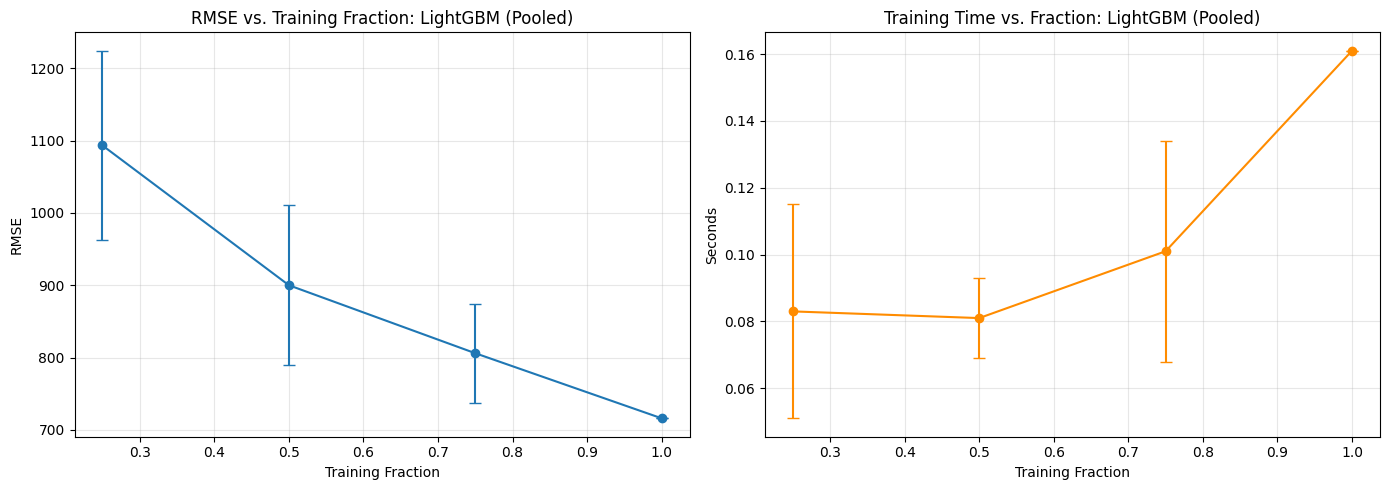

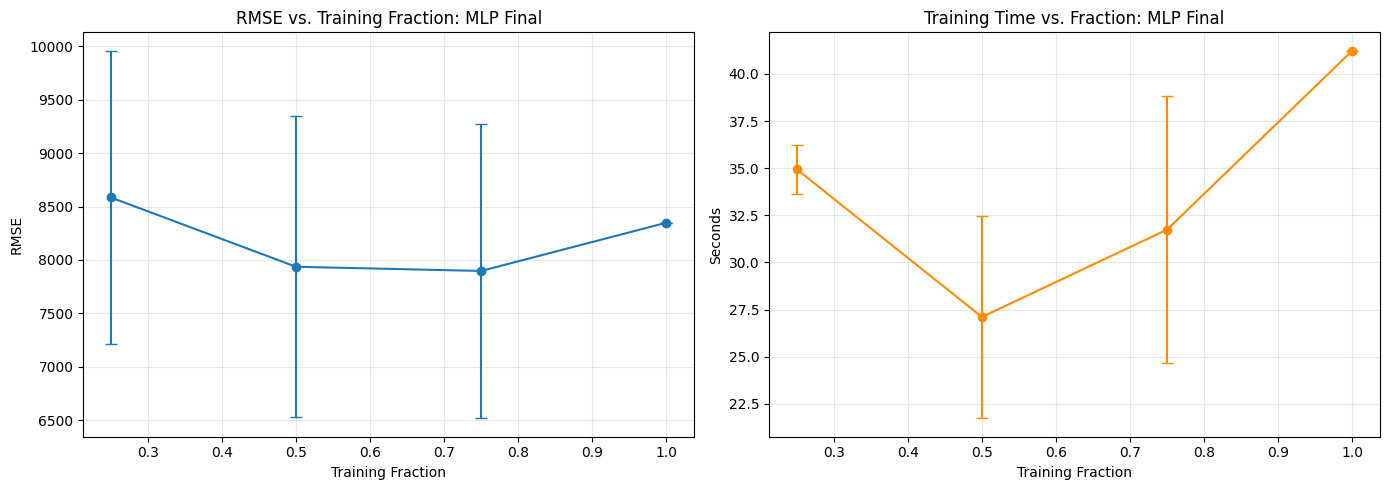

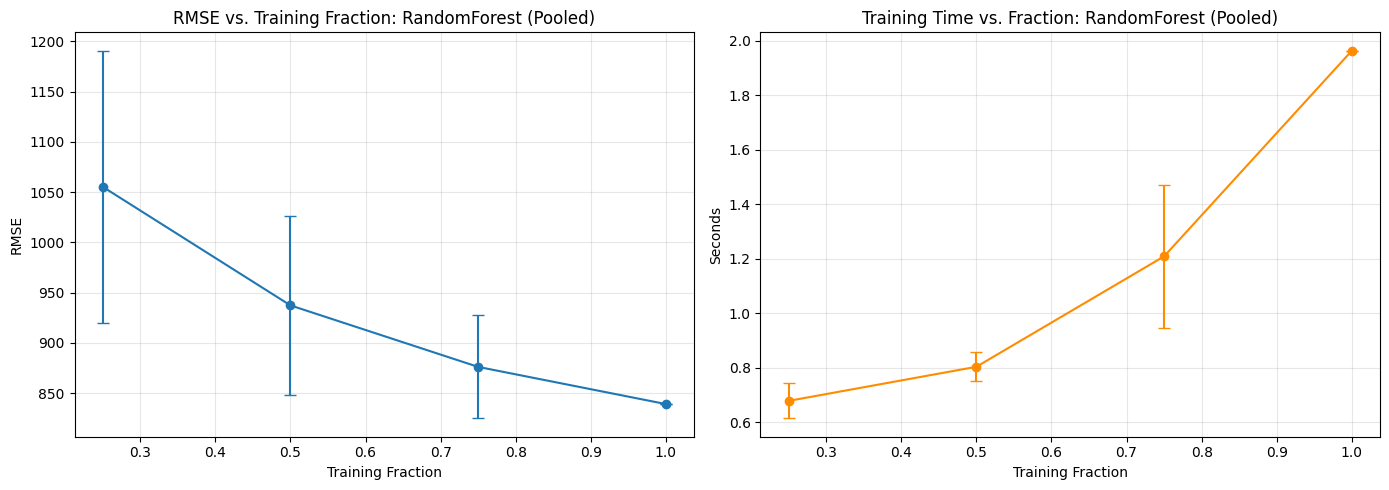

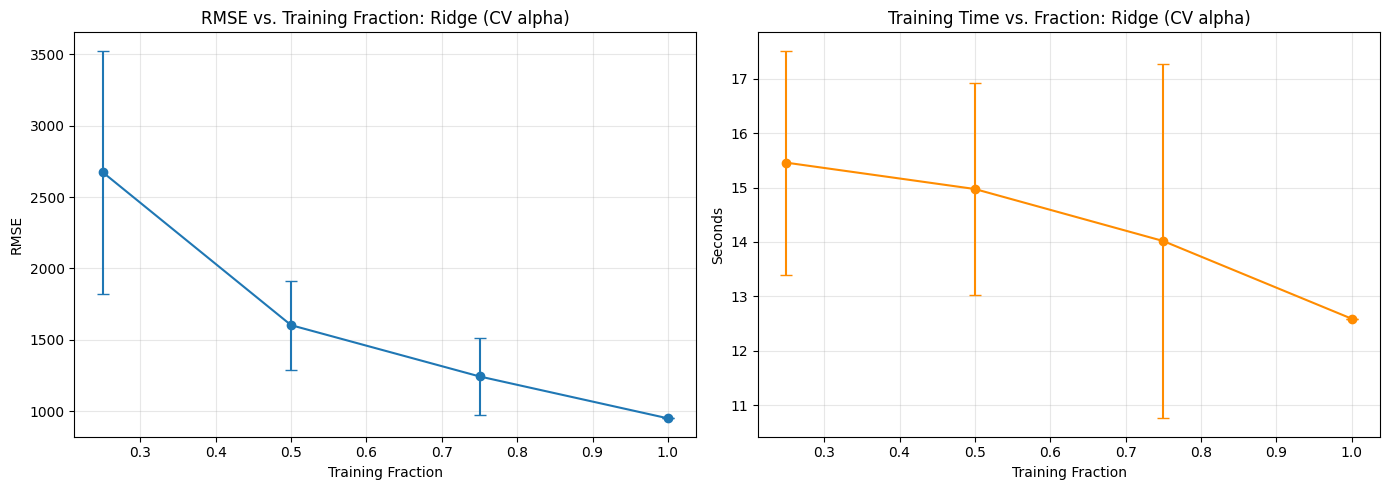

In [15]:
for model_name, group in fraction_summary_df.groupby('model_name'):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].errorbar(group['train_fraction'], group['RMSE_mean'],
                     yerr=group['RMSE_std'].fillna(0), marker='o', capsize=4)
    axes[0].set_title(f'RMSE vs. Training Fraction: {model_name}')
    axes[0].set_xlabel('Training Fraction')
    axes[0].set_ylabel('RMSE')
    axes[0].grid(alpha=0.3)

    axes[1].errorbar(group['train_fraction'], group['fit_time_total_sec_mean'],
                     yerr=group['fit_time_total_sec_std'].fillna(0), marker='o', capsize=4, color='darkorange')
    axes[1].set_title(f'Training Time vs. Fraction: {model_name}')
    axes[1].set_xlabel('Training Fraction')
    axes[1].set_ylabel('Seconds')
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


## 6. Pareto vs Full Data

For every supported saved model, compare the full training set against a Pareto subset of the highest-volume store-category combinations.


In [16]:
pareto_train = pareto_subset_by_combo_volume(train_tune, top_share=0.8)

pareto_rows = []
for artifact_key, entry in supported_artifacts.items():
    meta = entry["metadata"]
    for name, subset_type, subset in [
        (f"{meta.get("model_name", artifact_key)} Pareto 80", "pareto_80", pareto_train),
        (f"{meta.get("model_name", artifact_key)} Full", "full", train_tune)
    ]:
        _, _, res = run_supported_model(subset, val, meta, artifact_key, random_state=42)
        pareto_rows.append({
            "artifact_key": artifact_key,
            "model_name": meta.get("model_name", artifact_key),
            "subset_label": name,
            "subset_type": subset_type,
            **res
        })

pareto_df = pd.DataFrame(pareto_rows)
pareto_df = pareto_df.round({"MAE": 0, "RMSE": 0, "MAPE": 1, "R2": 4, "fit_time_total_sec": 3, "fit_time_avg_sec": 3})
pareto_df


LightGBM (Pooled)                 MAE=    903  RMSE=  1,195  MAPE= 25.4%  R²=0.9766
LightGBM (Pooled)                 MAE=    413  RMSE=    716  MAPE=  4.5%  R²=0.9916


/Users/aeshagandhi/Downloads/MIDS-Sp26/IDS-705/ids705_project/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/aeshagandhi/Downloads/MIDS-Sp26/IDS-705/ids705_project/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/aeshagandhi/Downloads/MIDS-Sp26/IDS-705/ids705_project/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/aeshagandhi/Downloads/MIDS-Sp26/IDS-705/ids705_project/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_percept

MLP Final                         MAE=  9,455  RMSE= 12,153  MAPE= 51.2%  R²=-2.3222


/Users/aeshagandhi/Downloads/MIDS-Sp26/IDS-705/ids705_project/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/aeshagandhi/Downloads/MIDS-Sp26/IDS-705/ids705_project/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/aeshagandhi/Downloads/MIDS-Sp26/IDS-705/ids705_project/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/aeshagandhi/Downloads/MIDS-Sp26/IDS-705/ids705_project/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_percept

MLP Final                         MAE=  4,843  RMSE=  8,349  MAPE= 34.3%  R²=-0.1402
RandomForest (Pooled)             MAE=    804  RMSE=  1,106  MAPE= 20.3%  R²=0.9800
RandomForest (Pooled)             MAE=    473  RMSE=    839  MAPE=  5.0%  R²=0.9885
Ridge (CV alpha)                  MAE=    888  RMSE=  1,321  MAPE=  5.0%  R²=0.9608
Ridge (CV alpha)                  MAE=    539  RMSE=    949  MAPE=  5.3%  R²=0.9853


,artifact_key,model_name,subset_label,subset_type,MAE,RMSE,MAPE,R2,fit_time_total_sec,fit_time_avg_sec,estimated_params_per_model,estimated_total_params,active_models,model_type,model_scope
0,lightgbm,LightGBM (Pooled),LightGBM (Pooled) Pareto 80,pareto_80,903.0,1195.0,25.4,0.9766,0.044,0.044,NaN,NaN,1,lightgbm,pooled
1,lightgbm,LightGBM (Pooled),LightGBM (Pooled) Full,full,413.0,716.0,4.5,0.9916,0.076,0.076,NaN,NaN,1,lightgbm,pooled
2,mlp,MLP Final,MLP Final Pareto 80,pareto_80,9455.0,12153.0,51.2,-2.3222,10.110,0.722,1313.0,18382.0,14,mlp,per_combo
3,mlp,MLP Final,MLP Final Full,full,4843.0,8349.0,34.3,-0.1402,22.346,0.745,1313.0,39390.0,30,mlp,per_combo
4,random_forest,RandomForest (Pooled),RandomForest (Pooled) Pareto 80,pareto_80,804.0,1106.0,20.3,0.9800,0.614,0.614,NaN,NaN,1,random_forest,pooled
5,random_forest,RandomForest (Pooled),RandomForest (Pooled) Full,full,473.0,839.0,5.0,0.9885,1.074,1.074,NaN,NaN,1,random_forest,pooled
6,ridge,Ridge (CV alpha),Ridge (CV alpha) Pareto 80,pareto_80,888.0,1321.0,5.0,0.9608,5.855,0.418,NaN,NaN,14,ridge_cv,per_combo
7,ridge,Ridge (CV alpha),Ridge (CV alpha) Full,full,539.0,949.0,5.3,0.9853,12.165,0.405,NaN,NaN,30,ridge_cv,per_combo


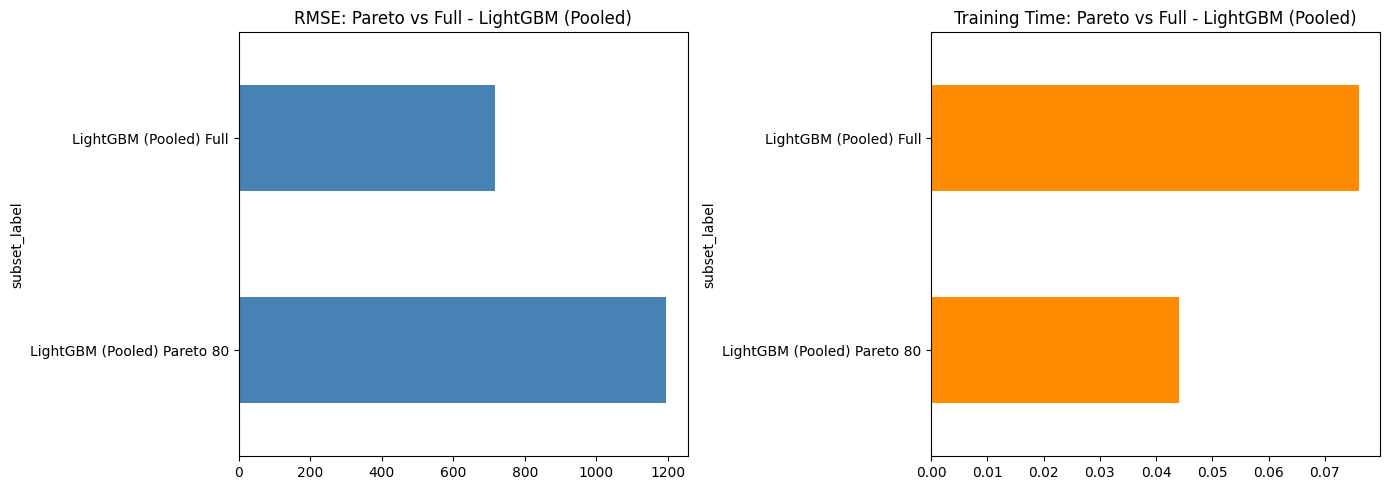

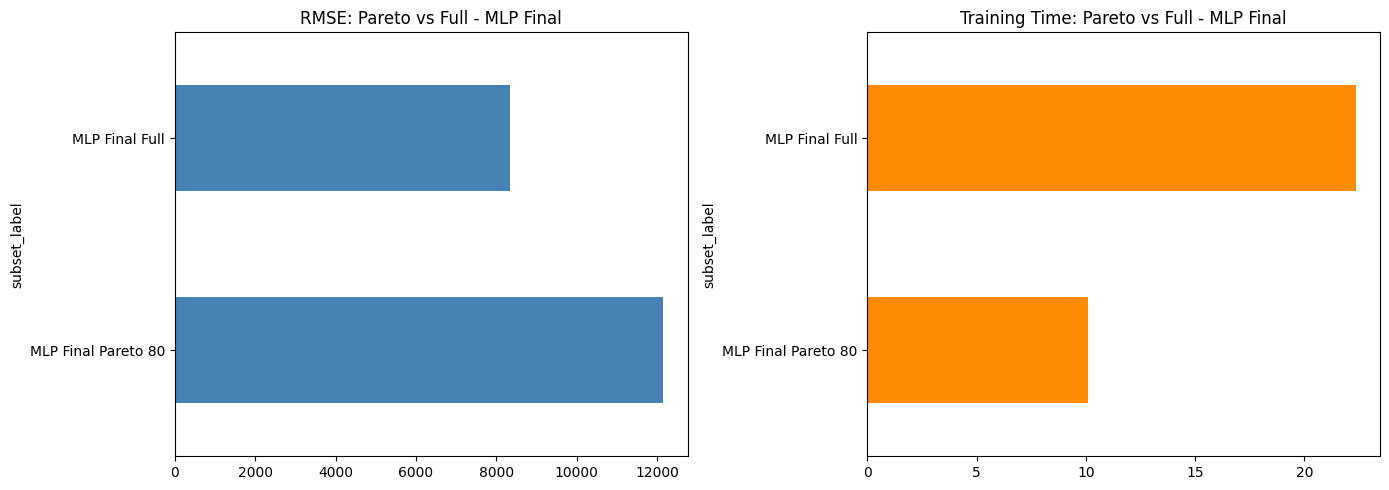

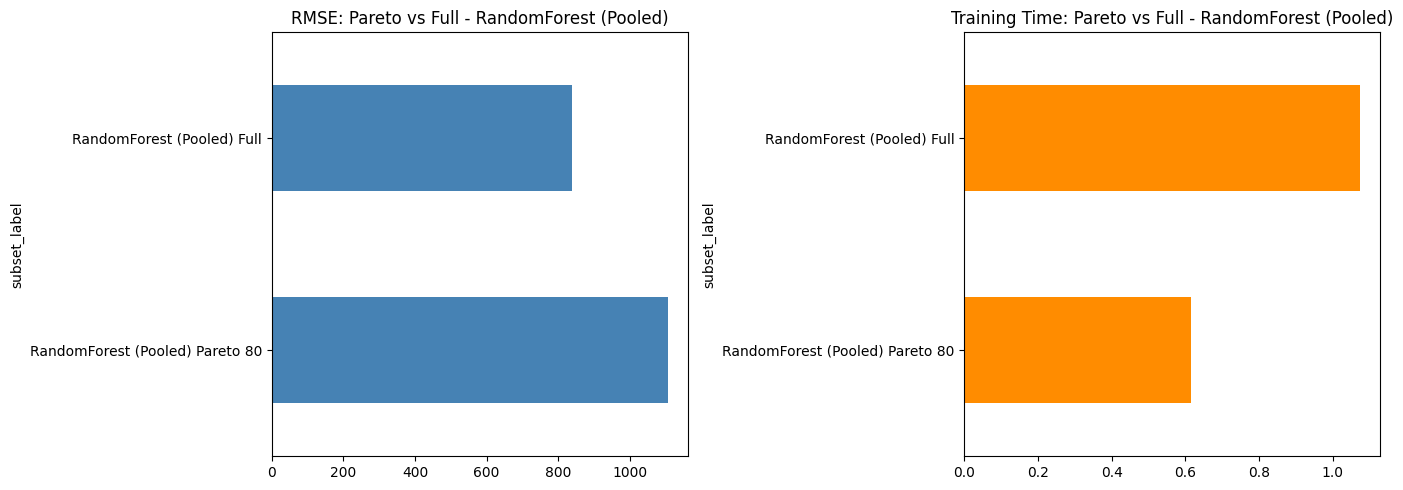

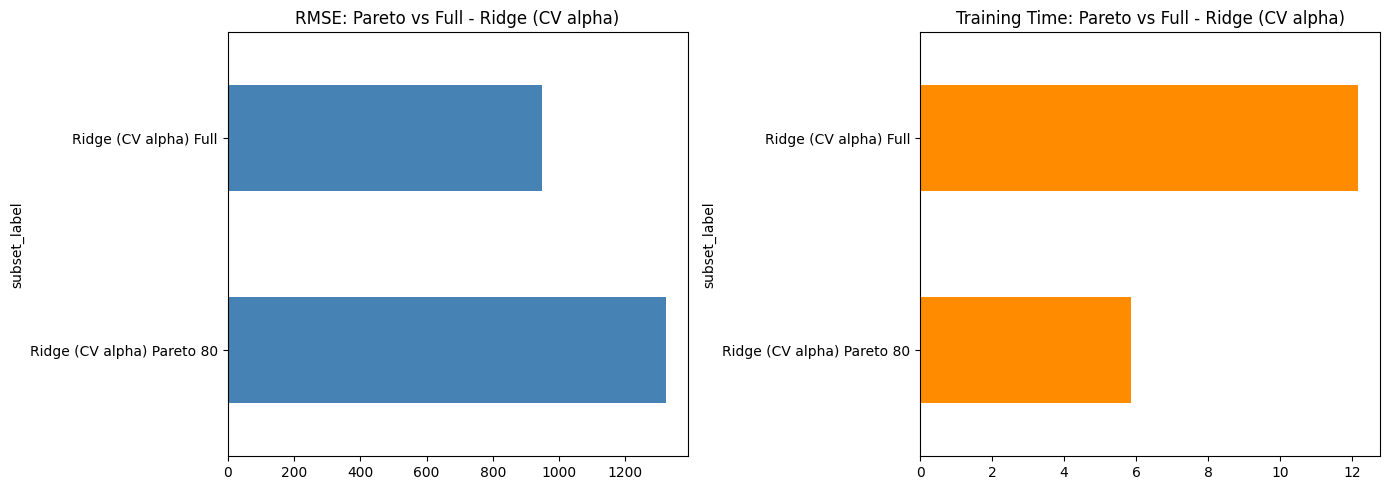

In [17]:
for model_name, group in pareto_df.groupby('model_name'):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    group.set_index('subset_label')['RMSE'].plot(kind='barh', ax=axes[0], color='steelblue')
    axes[0].set_title(f'RMSE: Pareto vs Full - {model_name}')

    group.set_index('subset_label')['fit_time_total_sec'].plot(kind='barh', ax=axes[1], color='darkorange')
    axes[1].set_title(f'Training Time: Pareto vs Full - {model_name}')

    plt.tight_layout()
    plt.show()


## 7. Interpretation Notes

When reading the fraction results:
- focus on both the average error and the standard deviation across repeated subsets
- if the mean stays low but the variance gets large at small fractions, the model may be unstable under limited data
- if the Pareto subset reduces runtime a lot with only modest error loss, that may be a practical tradeoff

Unsupported model metadata files will still be discovered and listed, but they will not be run until a matching training runner is added here.


## 8. Streamlining

For each model, save metadata in the same pattern under `artifacts/<model_name>/`. This notebook auto-discovers all `*_metadata.json` files under `artifacts/`, identifies supported model types, and runs the full data sufficiency workflow automatically for those models.
